## IntellNews Engine: A Comprehensive NLP Project

This project, 'IntellNews Engine', aims to demonstrate various Natural Language Processing (NLP) tasks using the AG News Classification Dataset. It includes news category prediction, emotion detection, trust score prediction, headline rewriting, and similar news recommendations, all integrated into an interactive interface.

### 1. Setup and Data Loading

In [6]:
# Install necessary libraries
!pip install pandas numpy nltk scikit-learn matplotlib wordcloud transformers textblob seaborn tensorflow --quiet

In [7]:
import pandas as pd
import numpy as np
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from transformers import pipeline # Import Hugging Face pipeline

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger') # Corrected typo from 'ltk'
nltk.download('punkt_tab') # Added to resolve LookupError

print("Libraries imported and NLTK data downloaded.")

Libraries imported and NLTK data downloaded.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#### Load the AG News Dataset
The AG News Classification Dataset consists of 4 categories: World, Sports, Business, and Sci/Tech. We will use the `train.csv` and `test.csv` files.

In [8]:
# Load the dataset
# Please upload 'train.csv' and 'test.csv' of the AG News Classification Dataset
# directly to your Google Colab environment's root directory.
# You can typically find these files on Kaggle or via public GitHub repositories.

try:
    train_df = pd.read_csv('train.csv', skiprows=1, names=['category', 'title', 'description'])
    test_df = pd.read_csv('test.csv', skiprows=1, names=['category', 'title', 'description'])
    print("Dataset loaded from uploaded local files.")
except FileNotFoundError:
    print("Error: 'train.csv' or 'test.csv' not found. Please upload them to your Colab environment.")
except Exception as e:
    print(f"An error occurred while loading the datasets: {e}")
    print("Please ensure the uploaded CSV files are correctly formatted.")

# Display basic information about the training data
if 'train_df' in locals():
    print("\nTrain Data Info:")
    display(train_df.info())
    display(train_df.head())

if 'test_df' in locals():
    print("\nTest Data Info:")
    display(test_df.info())
    display(test_df.head())

Dataset loaded from uploaded local files.

Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   category     120000 non-null  int64 
 1   title        120000 non-null  object
 2   description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


None

,category,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."



Test Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category     7600 non-null   int64 
 1   title        7600 non-null   object
 2   description  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB


None

,category,title,description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


### 2. NLP Preprocessing
This section handles various text preprocessing steps crucial for NLP tasks.

In [9]:
# Combine title and description for a comprehensive text
train_df['text'] = train_df['title'] + ' ' + train_df['description']
test_df['text'] = test_df['title'] + ' ' + test_df['description']

# Map numerical categories to meaningful names
category_map = {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}
# Convert 'category' column to numeric type before mapping
train_df['category'] = pd.to_numeric(train_df['category'])
test_df['category'] = pd.to_numeric(test_df['category'])

train_df['category_name'] = train_df['category'].map(category_map)
test_df['category_name'] = test_df['category'].map(category_map)

print("Combined 'title' and 'description' into 'text' and mapped categories.")
display(train_df.head())

Combined 'title' and 'description' into 'text' and mapped categories.


,category,title,description,text,category_name
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...,Business
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new...",Business


In [10]:
# Define preprocessing functions
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Lowercase conversion
    text = text.lower()

    # 2. Remove punctuation
    text = re.sub(r'[^a-z\s]', '', text) # Keep only letters and spaces

    # 3. Tokenization
    tokens = nltk.word_tokenize(text)

    # 4. Remove stopwords and 5. Lemmatization
    processed_tokens = []
    for token in tokens:
        if token not in stop_words:
            processed_tokens.append(lemmatizer.lemmatize(token))

    return ' '.join(processed_tokens)

# Apply preprocessing to the 'text' column
print("Applying preprocessing to training data...")
train_df['processed_text'] = train_df['text'].apply(preprocess_text)
print("Applying preprocessing to test data...")
test_df['processed_text'] = test_df['text'].apply(preprocess_text)

print("\nPreprocessing complete. Displaying first few rows with processed text:")
display(train_df[['text', 'processed_text', 'category_name']].head())

Applying preprocessing to training data...
Applying preprocessing to test data...

Preprocessing complete. Displaying first few rows with processed text:


,text,processed_text,category_name
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bear claw back black reuters reuters s...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle look toward commercial aerospace reute...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil economy cloud stock outlook reuters reuter...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halt oil export main southern pipeline re...,Business
4,"Oil prices soar to all-time record, posing new...",oil price soar alltime record posing new menac...,Business


### 3. News Category Prediction Model

This section focuses on classifying news articles into categories (World, Sports, Business, Sci/Tech) using TF-IDF for feature extraction and a machine learning model. We will use Logistic Regression as an example, but other models like Naive Bayes or SVM could also be used.

Training samples: 120000
Test samples: 7600

Applying TF-IDF feature extraction...
Shape of X_train_tfidf: (120000, 5000)
Shape of X_test_tfidf: (7600, 5000)

Training Logistic Regression model...
Model training complete.

Evaluating the model...
Accuracy: 0.9050

Classification Report:
              precision    recall  f1-score   support

    Business       0.87      0.87      0.87      1900
    Sci/Tech       0.88      0.88      0.88      1900
      Sports       0.94      0.98      0.96      1900
       World       0.92      0.90      0.91      1900

    accuracy                           0.91      7600
   macro avg       0.90      0.91      0.90      7600
weighted avg       0.90      0.91      0.90      7600


Confusion Matrix:


,Business,Sci/Tech,Sports,World
Business,1648,169,22,61
Sci/Tech,142,1665,29,64
Sports,13,12,1859,16
World,82,51,61,1706


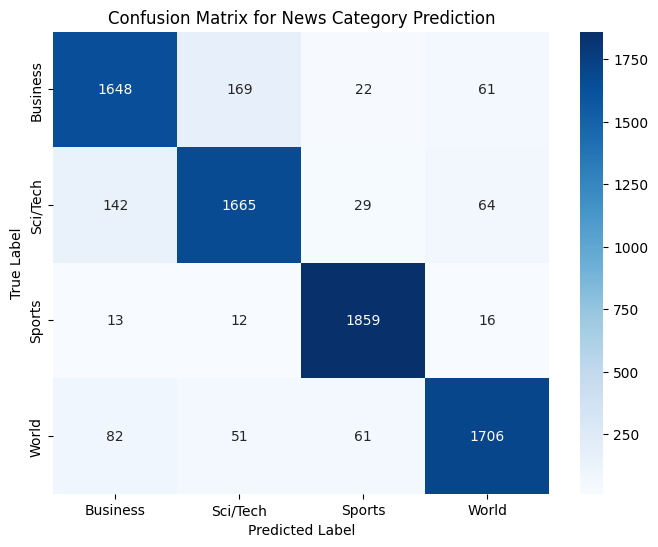

In [11]:
# Import necessary libraries for model building
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prepare data for modeling
X_train = train_df['processed_text']
y_train = train_df['category_name']
X_test = test_df['processed_text']
y_test = test_df['category_name']

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# 3.1 TF-IDF Feature Extraction
print("\nApplying TF-IDF feature extraction...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features for performance
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

# 3.2 Model Training (Logistic Regression)
print("\nTraining Logistic Regression model...")
logistic_model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
logistic_model.fit(X_train_tfidf, y_train)
print("Model training complete.")

# 3.3 Model Evaluation
print("\nEvaluating the model...")
y_pred = logistic_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(conf_matrix, index=logistic_model.classes_, columns=logistic_model.classes_))

# Plotting Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=logistic_model.classes_, yticklabels=logistic_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for News Category Prediction')
plt.show()

#### Predicted Category Distribution
This bar chart shows the distribution of categories as predicted by the Logistic Regression model on the test set.

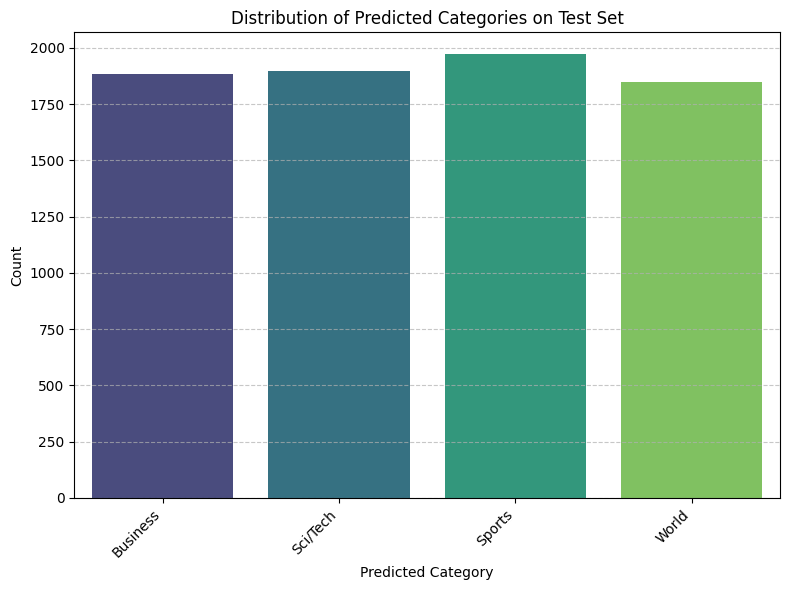

In [12]:
# Predicted Category Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=y_pred, order=logistic_model.classes_, palette='viridis', hue=y_pred, legend=False)
plt.title('Distribution of Predicted Categories on Test Set')
plt.xlabel('Predicted Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Correctly vs. Incorrectly Classified Articles
This visualization compares the true labels with the predicted labels to show how many articles were correctly and incorrectly classified for each category.

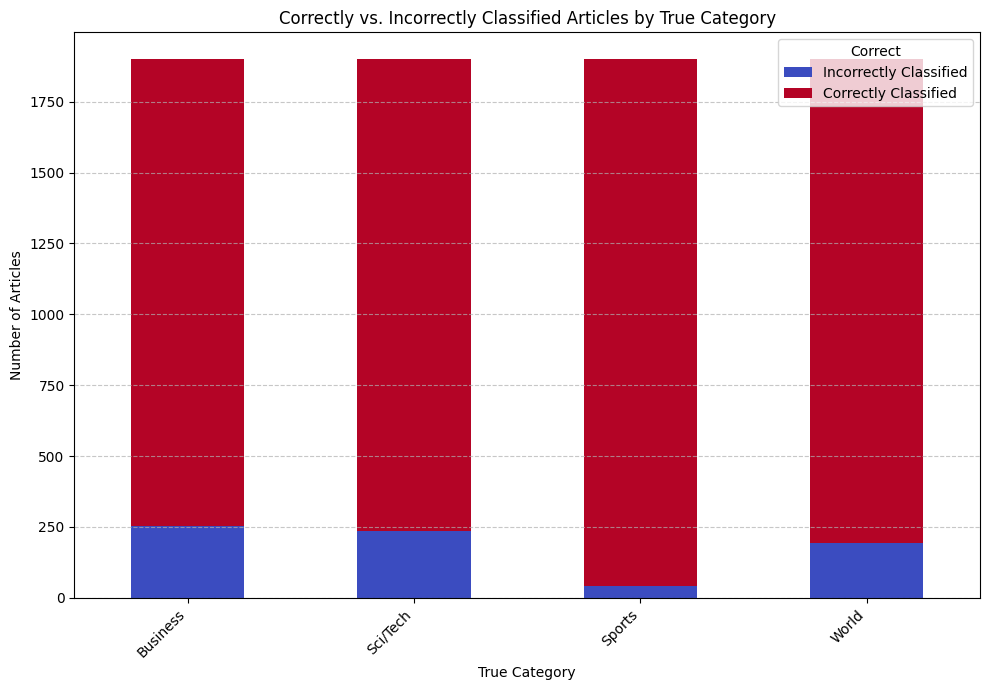

In [13]:
# Create a DataFrame for comparison
comparison_df = pd.DataFrame({'True_Label': y_test, 'Predicted_Label': y_pred})
comparison_df['Correct'] = (comparison_df['True_Label'] == comparison_df['Predicted_Label'])

# Group by true label and count correct/incorrect
performance_by_category = comparison_df.groupby('True_Label')['Correct'].value_counts().unstack(fill_value=0)
performance_by_category = performance_by_category.rename(columns={True: 'Correctly Classified', False: 'Incorrectly Classified'})

# Plotting
performance_by_category.plot(kind='bar', stacked=True, figsize=(10, 7), cmap='coolwarm')
plt.title('Correctly vs. Incorrectly Classified Articles by True Category')
plt.xlabel('True Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Confusion Matrix
This heatmap visualizes the confusion matrix, showing the counts of true vs. predicted labels for each news category.

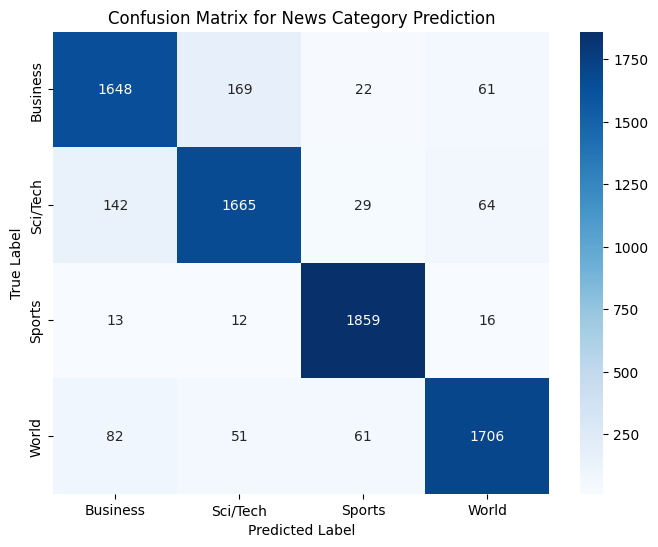

In [14]:
# Plotting Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=logistic_model.classes_, yticklabels=logistic_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for News Category Prediction')
plt.show()

### 4. Emotion Detection

This module will detect emotions in headlines using `textblob`. While `textblob` primarily provides sentiment (polarity and subjectivity), we can interpret these as basic emotional indicators (e.g., positive, negative, neutral) and extend this with a rule-based system or more advanced models if needed for specific emotions like 'fear', 'excitement', etc. For simplicity and as a starting point, we'll use `textblob`'s sentiment.

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Applying emotion detection to test data headlines...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Emotion detection complete. Displaying first few rows with detected emotion:


,title,emotion
0,Fears for T N pension after talks,Negative
1,The Race is On: Second Private Team Sets Launc...,Negative
2,Ky. Company Wins Grant to Study Peptides (AP),Positive
3,Prediction Unit Helps Forecast Wildfires (AP),Positive
4,Calif. Aims to Limit Farm-Related Smog (AP),Negative



Generating Emotion Distribution Graph...


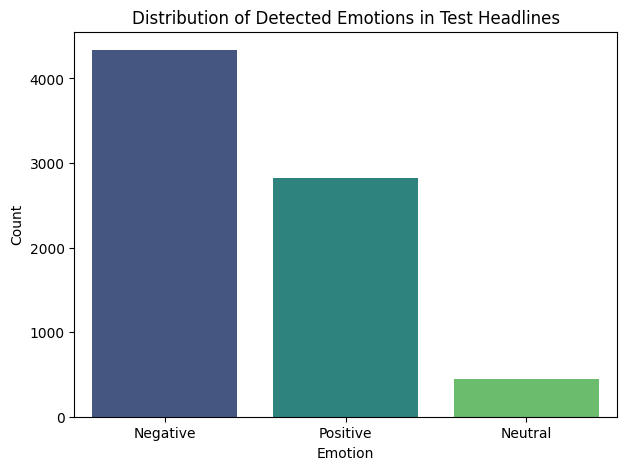

In [15]:
# Initialize the Hugging Face sentiment analysis pipeline
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def get_sentiment_emotion(text):
    if not text or not isinstance(text, str): # Handle empty or non-string input
        return 'Neutral'
    result = sentiment_pipeline(text)[0]
    label = result['label']
    score = result['score']

    # Map Hugging Face labels to desired output, incorporating a neutral threshold
    # If confidence is low (e.g., less than 70%), consider it neutral
    if score < 0.7:
        return 'Neutral'
    elif label == 'POSITIVE':
        return 'Positive'
    elif label == 'NEGATIVE':
        return 'Negative'
    return 'Neutral' # Fallback for unexpected cases

# Apply emotion detection to the 'description' or 'title' column of the test set
# Using 'title' for conciseness as requested for 'headlines'
print("Applying emotion detection to test data headlines...")
test_df['emotion'] = test_df['title'].apply(get_sentiment_emotion)

print("Emotion detection complete. Displaying first few rows with detected emotion:")
display(test_df[['title', 'emotion']].head())

# 9.2 Emotion Distribution Graph
print("\nGenerating Emotion Distribution Graph...")
plt.figure(figsize=(7, 5))
sns.countplot(x='emotion', data=test_df, palette='viridis', hue='emotion', legend=False)
plt.title('Distribution of Detected Emotions in Test Headlines')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.show()

### Function to Apply Sentiment to Description Column

This function will extend the sentiment analysis to the `description` column of the DataFrame using the pre-configured Hugging Face sentiment pipeline.

In [16]:
def apply_sentiment_to_description(df):
    print("Applying emotion detection to description column...")
    df['description_emotion'] = df['description'].apply(get_sentiment_emotion)
    print("Emotion detection for description complete.")
    return df

# Example usage on train_df
# Ensure 'train_df' is defined from previous data loading and preprocessing steps.
if 'train_df' in globals():
    train_df = apply_sentiment_to_description(train_df)
    display(train_df[['description', 'description_emotion']].head())
else:
    print("Error: 'train_df' is not defined. Please ensure data loading and preprocessing cells (like 611e04ba, f17c14c7, 3c2ea11e) have been run.")

Applying emotion detection to description column...
Emotion detection for description complete.


,description,description_emotion
0,"Reuters - Short-sellers, Wall Street's dwindli...",Positive
1,Reuters - Private investment firm Carlyle Grou...,Positive
2,Reuters - Soaring crude prices plus worries\ab...,Negative
3,Reuters - Authorities have halted oil export\f...,Negative
4,"AFP - Tearaway world oil prices, toppling reco...",Negative


### 5. Trust Score Prediction System

#### Trust Score Distribution
This histogram shows the distribution of trust scores calculated for the headlines, giving an insight into the perceived trustworthiness of the news.

In [17]:
# # Visualize the distribution of trust scores
# plt.figure(figsize=(10, 6))
# sns.histplot(test_df['trust_score'], bins=20, kde=True, palette='viridis')
# plt.title('Distribution of Trust Scores in Test Headlines')
# plt.xlabel('Trust Score (0-100)')
# plt.ylabel('Number of Headlines')
# plt.grid(axis='y', alpha=0.75)
# plt.show()

This system aims to predict a 'trust score' for a given headline based on several heuristic factors that often indicate clickbait or sensationalism. The score will range from 0 (least trustworthy) to 100 (most trustworthy).

Calculating trust scores for test data headlines...
Trust score calculation complete. Displaying first few rows with scores:


,title,trust_score
0,Fears for T N pension after talks,100
1,The Race is On: Second Private Team Sets Launc...,100
2,Ky. Company Wins Grant to Study Peptides (AP),100
3,Prediction Unit Helps Forecast Wildfires (AP),100
4,Calif. Aims to Limit Farm-Related Smog (AP),100



Generating Trust Score Distribution Graph...


/tmp/ipykernel_559/1655490845.py:57: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(test_df['trust_score'], bins=20, kde=True, palette='viridis')


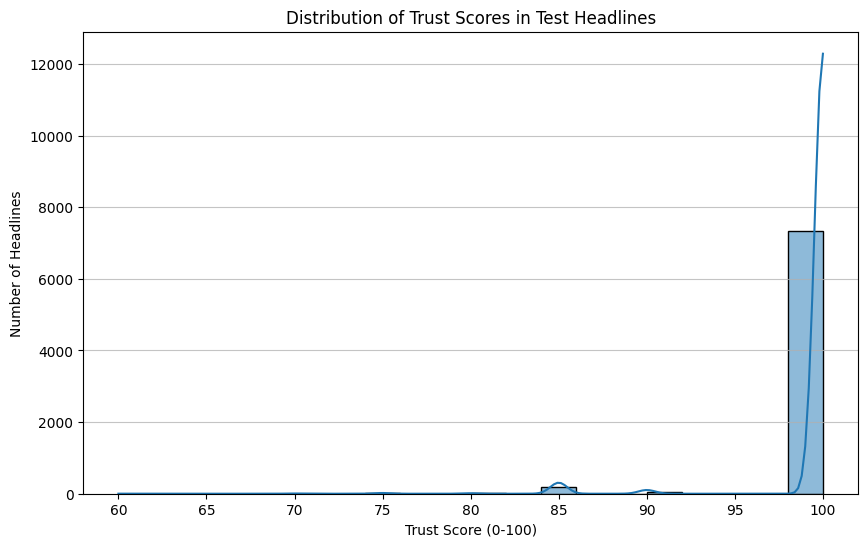

In [19]:
from textblob import TextBlob # Import TextBlob

# Define lists of keywords for analysis
clickbait_keywords = [
    'shocking', 'unbelievable', 'secret', 'revealed', 'never believe',
    'epic', 'fail', 'gone wrong', 'must see', 'you won\'t believe',
    'hacks', 'tricks', 'amazing', 'incredible', 'insane', 'genius',
    'mind-blowing', 'viral', 'transforms', 'flips', 'crazy', 'worst',
    'best', 'how to', 'what happens when'
]

def calculate_trust_score(headline):
    score = 100 # Start with a perfect score

    # 1. Check for Excessive Punctuation (e.g., multiple '!' or '?')
    exclamation_count = headline.count('!')
    question_count = headline.count('?')
    if exclamation_count > 1 or question_count > 1 or (exclamation_count > 0 and question_count > 0):
        score -= 20

    # 2. Check for Capitalized Words (more than 2 all-caps words that are not acronyms)
    words = headline.split()
    all_caps_words = [word for word in words if word.isupper() and len(word) > 1]
    if len(all_caps_words) > 2:
        score -= 15

    # 3. Check for Clickbait Keywords
    headline_lower = headline.lower()
    for keyword in clickbait_keywords:
        if keyword in headline_lower:
            score -= 10
            # Penalize more for multiple clickbait keywords
            if headline_lower.count(keyword) > 1:
                score -= 5

    # 4. Check for Emotional Exaggeration (using TextBlob sentiment polarity)
    analysis = TextBlob(headline)
    polarity = analysis.sentiment.polarity
    # Penalize for extremely positive or negative sentiment (exaggeration)
    if abs(polarity) > 0.7: # High polarity indicates strong emotion
        score -= 15

    # Ensure score is within 0-100 range
    score = max(0, min(100, score))
    return score

# Apply trust score calculation to the test set headlines
print("Calculating trust scores for test data headlines...")
test_df['trust_score'] = test_df['title'].apply(calculate_trust_score)

print("Trust score calculation complete. Displaying first few rows with scores:")
display(test_df[['title', 'trust_score']].head())

# Visualize the distribution of trust scores
print("\nGenerating Trust Score Distribution Graph...")
plt.figure(figsize=(10, 6))
sns.histplot(test_df['trust_score'], bins=20, kde=True, palette='viridis')
plt.title('Distribution of Trust Scores in Test Headlines')
plt.xlabel('Trust Score (0-100)')
plt.ylabel('Number of Headlines')
plt.grid(axis='y', alpha=0.75)
plt.show()

### 6. Headline Rewriter Module

This module will rewrite news headlines into different styles: professional, clickbait, social media, and formal. For this, we'll leverage rule-based transformations and potentially simple text modifications.

In [20]:
import random

def rewrite_headline(headline, style='professional'):
    headline = headline.strip()

    if style == 'professional':
        # Professional: Focus on conciseness, objectivity, and formal language
        # Remove exclamation/question marks, excessive capitalization, informal words
        rewritten = headline.replace('!', '').replace('?', '')
        rewritten = ' '.join([word.capitalize() if word.isupper() else word for word in rewritten.split()])
        rewritten = rewritten.replace('...', '')
        if not rewritten.endswith('.'):
            rewritten += '.'
        return rewritten

    elif style == 'clickbait':
        # Clickbait: Use exaggeration, questions, numbers, strong adjectives
        clickbait_starters = [
            "You Won't Believe What Happened Next: ",
            "Shocking: ",
            "This Secret Was Just Revealed: ",
            "[Number] Things You Need To Know About ",
            "The Truth About ",
            "Why Everyone Is Talking About ",
            "Gone Wrong: "
        ]
        clickbait_phrases = [
            " -- It's Insane!",
            " -- Find Out Now!",
            " -- The Internet Is Exploding!",
            " -- What Happens Next Is Unbelievable!"
        ]
        num = random.randint(3, 10)
        starter = random.choice(clickbait_starters).replace('[Number]', str(num))
        phrase = random.choice(clickbait_phrases)

        rewritten = starter + headline.replace('.', '') + phrase
        return rewritten

    elif style == 'social_media':
        # Social Media: Use hashtags, emojis, informal tone, calls to action
        emojis = ['🔥', '💡', '📰', '🤩', '🚀']
        hashtags = ['#BreakingNews', '#NewsUpdate', '#MustRead', '#Trending', '#DailyNews']
        call_to_action = random.choice(['Check it out!', 'Thoughts?', 'Share this!'])

        rewritten = f"{random.choice(emojis)} {headline.replace('.', '')} {random.choice(hashtags)} {call_to_action}"
        return rewritten

    elif style == 'formal':
        # Formal: Emphasize objective reporting, proper grammar, no sensationalism
        # Similar to professional but perhaps even more structured and less 'catchy'S
        rewritten = headline.replace('!', '').replace('?', '').replace('...', '')
        rewritten = rewritten.capitalize()
        if not rewritten.endswith('.'):
            rewritten += '.'
        return rewritten

    return headline # Default if style not recognized

# Example Usage:
example_headline = test_df['title'].iloc[0]
print(f"Original Headline: {example_headline}")
print(f"Professional Style: {rewrite_headline(example_headline, 'professional')}")
print(f"Clickbait Style: {rewrite_headline(example_headline, 'clickbait')}")
print(f"Social Media Style: {rewrite_headline(example_headline, 'social_media')}")
print(f"Formal Style: {rewrite_headline(example_headline, 'formal')}")

Original Headline: Fears for T N pension after talks
Professional Style: Fears for T N pension after talks.
Clickbait Style: Why Everyone Is Talking About Fears for T N pension after talks -- The Internet Is Exploding!
Social Media Style: 📰 Fears for T N pension after talks #MustRead Share this!
Formal Style: Fears for t n pension after talks.


### 7. Similarity Recommendation Engine

This module will recommend news headlines similar to a given input headline. We will use TF-IDF features and cosine similarity to find the most similar articles from our dataset.

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

# We will reuse the tfidf_vectorizer fitted on the training data
# and apply it to all processed text for similarity calculations.

# Combine train and test processed text for a larger pool of articles for recommendations
all_processed_text = pd.concat([train_df['processed_text'], test_df['processed_text']], ignore_index=True)
all_titles = pd.concat([train_df['title'], test_df['title']], ignore_index=True)

# Create TF-IDF matrix for all articles
print("Creating TF-IDF matrix for all articles for similarity calculations...")
# It's important to fit the TfidfVectorizer only on the training data to avoid data leakage
# However, for recommendation, we want to transform all available data (train+test) using the fitted vectorizer
all_articles_tfidf = tfidf_vectorizer.transform(all_processed_text)
print("TF-IDF matrix created.")

def recommend_similar_news(headline, num_recommendations=5):
    # Preprocess the input headline
    processed_headline = preprocess_text(headline)

    # Transform the processed headline using the fitted TF-IDF vectorizer
    headline_tfidf = tfidf_vectorizer.transform([processed_headline])

    # Calculate cosine similarity between the input headline and all articles
    similarities = cosine_similarity(headline_tfidf, all_articles_tfidf).flatten()

    # Get the indices of the most similar articles (excluding itself if present)
    # Sort in descending order and get the top N
    # We create a series to easily get titles later and sort values
    similarity_series = pd.Series(similarities)
    top_indices = similarity_series.nlargest(num_recommendations + 1).index.tolist()

    # Exclude the input headline's own index if it's identical to one in the dataset
    # For simplicity, we assume the input headline won't be perfectly identical to one of the top N
    # If it is, we would need to handle that by perhaps checking the original title content

    recommendations = []
    for i in top_indices:
        if all_titles.iloc[i].lower() != headline.lower(): # Avoid recommending the exact same headline
            recommendations.append(all_titles.iloc[i])
        if len(recommendations) == num_recommendations:
            break

    return recommendations

# Example Usage:
example_headline = "Microsoft plans new search engine for better competition"
print(f"\nOriginal Headline: {example_headline}")
similar_news = recommend_similar_news(example_headline)
print("\nSimilar News Recommendations:")
for i, news in enumerate(similar_news):
    print(f"{i+1}. {news}")

example_headline_2 = "World Cup final sees record viewership"
print(f"\nOriginal Headline: {example_headline_2}")
similar_news_2 = recommend_similar_news(example_headline_2)
print("\nSimilar News Recommendations:")
for i, news in enumerate(similar_news_2):
    print(f"{i+1}. {news}")

Creating TF-IDF matrix for all articles for similarity calculations...
TF-IDF matrix created.

Original Headline: Microsoft plans new search engine for better competition

Similar News Recommendations:
1. Search Engines and Competitive Research
2. Microsoft readies new search engine
3. Microsoft to launch new search engine
4. Microsoft to showcase new MSN Search preview
5. Understanding Search Engine Models

Original Headline: World Cup final sees record viewership

Similar News Recommendations:
1. Davis Cup final to break spectator records
2. First the game, then ...
3. Runaway Miller equals record
4. Skiing: Paerson wins World Cup giant slalom
5. Myskinia heads all-Russian final


### 8. & 9. Performance Metrics & Data Visualization

Performance metrics (Accuracy, Classification Report, Confusion Matrix) and several data visualizations (Category Distribution, Emotion Distribution, Trust Score Distribution) have already been generated and displayed within their respective sections (Sections 3, 4, and 5) as the models and analyses were performed. This ensures that the results are presented immediately after their computation.

### 10. Interactive Interface

Finally, we will create an interactive interface where a user can input a headline and receive all the analyses from the previous modules: predicted category, emotion detected, trust score, rewritten headlines in different styles, and similar news recommendations.

In [22]:
import pandas as pd
import datetime

# Initialize a DataFrame to store feedback
feedback_df = pd.DataFrame(columns=[
    'original_headline', 'predicted_category', 'corrected_category',
    'predicted_emotion', 'corrected_emotion',
    'predicted_trust_score', 'corrected_trust_score', 'feedback_comment',
    'timestamp'
])

print("Feedback DataFrame initialized.")
# Display the empty DataFrame to show its structure
display(feedback_df.head())

Feedback DataFrame initialized.


,original_headline,predicted_category,corrected_category,predicted_emotion,corrected_emotion,predicted_trust_score,corrected_trust_score,feedback_comment,timestamp


In [23]:
from IPython.display import display, HTML
import ipywidgets as widgets

def analyze_headline(headline):
    # 1. News Category Prediction
    processed_headline = preprocess_text(headline)
    headline_tfidf = tfidf_vectorizer.transform([processed_headline])
    predicted_category = logistic_model.predict(headline_tfidf)[0]

    # 2. Emotion Detection
    detected_emotion = get_sentiment_emotion(headline)

    # 3. Trust Score Prediction
    trust_score = calculate_trust_score(headline)

    # 4. Headline Rewriter
    rewritten_professional = rewrite_headline(headline, 'professional')
    rewritten_clickbait = rewrite_headline(headline, 'clickbait')
    rewritten_social_media = rewrite_headline(headline, 'social_media')
    rewritten_formal = rewrite_headline(headline, 'formal')

    # 5. Similarity Recommendation Engine
    similar_news = recommend_similar_news(headline)

    # Display results
    output_str = f"<h3>Analysis for: '{headline}'</h3>"
    output_str += f"<p><b>Predicted Category:</b> {predicted_category}</p>"
    output_str += f"<p><b>Detected Emotion:</b> {detected_emotion}</p>"
    output_str += f"<p><b>Trust Score:</b> {trust_score:.2f}/100</p>"

    output_str += "<h4>Rewritten Headlines:</h4>"
    output_str += f"<p><b>Professional:</b> {rewritten_professional}</p>"
    output_str += f"<p><b>Clickbait:</b> {rewritten_clickbait}</p>"
    output_str += f"<p><b>Social Media:</b> {rewritten_social_media}</p>"
    output_str += f"<p><b>Formal:</b> {rewritten_formal}</p>"

    output_str += "<h4>Similar News Recommendations:</h4>"
    if similar_news:
        output_str += "<ul>"
        for news in similar_news:
            output_str += f"<li>{news}</li>"
        output_str += "</ul>"
    else:
        output_str += "<p>No similar news found.</p>"

    display(HTML(output_str))

    # --- Feedback Section ---
    feedback_output = widgets.Output()

    category_options = list(category_map.values())
    emotion_options = ['Positive', 'Negative', 'Neutral']

    corrected_category_dropdown = widgets.Dropdown(
        options=['None'] + category_options,
        value='None',
        description='Correct Category:',
        disabled=False,
    )

    corrected_emotion_dropdown = widgets.Dropdown(
        options=['None'] + emotion_options,
        value='None',
        description='Correct Emotion:',
        disabled=False,
    )

    corrected_trust_score_slider = widgets.IntSlider(
        value=int(trust_score),
        min=0,
        max=100,
        step=1,
        description='Correct Trust Score:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='d'
    )

    feedback_comment_textarea = widgets.Textarea(
        value='',
        placeholder='Optional: Add comments or suggestions',
        description='Comments:',
        disabled=False,
        layout=widgets.Layout(width='80%', height='60px')
    )

    submit_feedback_button = widgets.Button(
        description='Submit Feedback',
        disabled=False,
        button_style='info',
        tooltip='Submit your corrections and comments',
        icon='send'
    )

    def on_submit_feedback_button_click(b):
        global feedback_df
        new_feedback = {
            'original_headline': headline,
            'predicted_category': predicted_category,
            'corrected_category': corrected_category_dropdown.value if corrected_category_dropdown.value != 'None' else None,
            'predicted_emotion': detected_emotion,
            'corrected_emotion': corrected_emotion_dropdown.value if corrected_emotion_dropdown.value != 'None' else None,
            'predicted_trust_score': trust_score,
            'corrected_trust_score': corrected_trust_score_slider.value if corrected_trust_score_slider.value != int(trust_score) else None,
            'feedback_comment': feedback_comment_textarea.value,
            'timestamp': datetime.datetime.now()
        }
        feedback_df = pd.concat([feedback_df, pd.DataFrame([new_feedback])], ignore_index=True)
        with feedback_output:
            feedback_output.clear_output()
            display(HTML("<p style='color:green;'>Feedback submitted successfully!</p>"))
            display(feedback_df.tail())

    submit_feedback_button.on_click(on_submit_feedback_button_click)

    feedback_widgets = widgets.VBox([
        widgets.HTML("<h4>Provide Feedback (Optional):</h4>"), # Changed here
        corrected_category_dropdown,
        corrected_emotion_dropdown,
        corrected_trust_score_slider,
        feedback_comment_textarea,
        submit_feedback_button,
        feedback_output
    ])
    display(feedback_widgets)

# Create interactive widgets for headline input and analysis trigger
headline_input = widgets.Textarea(
    value='Scientists discover new exoplanet with signs of water',
    placeholder='Enter news headline here',
    description='Headline:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='80px')
)

analyze_button = widgets.Button(
    description='Analyze Headline',
    disabled=False,
    button_style='success',
    tooltip='Click to analyze the headline',
    icon='check'
)

output_area = widgets.Output()

def on_button_click(b):
    with output_area:
        output_area.clear_output()
        analyze_headline(headline_input.value)

analyze_button.on_click(on_button_click)

display(headline_input, analyze_button, output_area)


Textarea(value='Scientists discover new exoplanet with signs of water', description='Headline:', layout=Layout…

Button(button_style='success', description='Analyze Headline', icon='check', style=ButtonStyle(), tooltip='Cli…

Output()